# GPS-IMU State Estimation

This notebook demonstrates sensor fusion with two estimators to illustrate the
difference between `sync_mode="any"` and `sync_mode="all"`.

## System Overview

$$
\underbrace{\text{GPS}_{1\,\text{Hz}}}_{\text{position}} \;\;\&\;\;
\underbrace{\text{IMU}_{100\,\text{Hz}}}_{\text{acceleration}}
\;\xrightarrow{}\;
\begin{cases}
  \text{Kalman Filter} & \texttt{sync\_mode=\textquotedbl{}any\textquotedbl{}} \\
  \text{ANN (stub)}    & \texttt{sync\_mode=\textquotedbl{}all\textquotedbl{}}
\end{cases}
\;\xrightarrow{}\; \hat{x}_k
$$

| Node | Rate | Message | Field used | Noise |
|------|------|---------|------------|-------|
| GPS  | 1 Hz | `NavSatFix` | `latitude` = position | σ = 5 m |
| IMU  | 100 Hz | `sensor_msgs/Imu` | `linear_acceleration.x` (index 7) | σ = 0.5 m/s² |

**KF** (`sync_mode="any"`) fires on every incoming message — ~101 Hz total.
It predicts using IMU acceleration every tick and corrects using GPS when available.

**ANN** (`sync_mode="all"`) fires only when *both* `/gps` and `/imu` are fresh simultaneously.
Since IMU (100 Hz, `stale_after=0.02 s`) is almost always fresh, the bottleneck is GPS
(1 Hz, `stale_after=2.0 s`), so the ANN fires at ~1 Hz.

The ANN uses pre-set random weights (untrained stub) — the output is meaningless,
but the sync behaviour is what this notebook illustrates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dynamicalnodes import DynamicalSystem

## Component Definitions

Each component is a `DynamicalSystem(f=..., h=...)` where:
- `f(x_k, ...)` → `x_{k+1}` updates the internal state
- `h(x_k, ...)` → `y_k` produces the observable output

The GPS and IMU simulator blocks are stateless — their output is a deterministic
function of time `tk`. Noise is added externally in the simulation loop.

### GPS Simulator

Stateless: returns a `NavSatFix`-compatible array `[lat=x, lon=0, alt=0]`
from the true sinusoidal trajectory.

In [2]:
def gps_h(tk, A, omega):
    x_true = A * np.sin(omega * tk)
    return np.array([x_true, 0.0, 0.0])  # [lat=x, lon=0, alt=0]


gps_block = DynamicalSystem(h=gps_h)

### IMU Simulator

Stateless: returns an `Imu`-compatible array with `linear_acceleration.x` set
to the true acceleration (index 7 in the ros2py_imu layout).

Layout: `[ori.x, ori.y, ori.z, ori.w, gyro.x, gyro.y, gyro.z, acc.x, acc.y, acc.z]`

In [3]:
def imu_h(tk, A, omega):
    ax = -A * omega**2 * np.sin(omega * tk)  # true acceleration
    return np.array([0.0, 0.0, 0.0, 1.0,  # orientation (unit quaternion)
                     0.0, 0.0, 0.0,         # angular velocity
                     ax,  0.0, 0.0])         # linear acceleration


imu_block = DynamicalSystem(h=imu_h)

### Kalman Filter

State: $z_k = (\hat{x}_k,\, P_k)$ — position/velocity estimate and covariance.

IMU acceleration drives the **predict** step on every tick.
GPS position triggers a **measurement update** only when `gps is not None`.
Passing `gps=None` (on non-GPS ticks) skips the update — only predicting.

$$
\hat{x}_{k|k-1} = F_k \hat{x}_{k-1} + B_k a_x, \qquad
P_{k|k-1} = F_k P_{k-1} F_k^\top + Q_k
$$

$$
K_k = P_{k|k-1} H^\top S^{-1}, \quad
\hat{x}_k = \hat{x}_{k|k-1} + K_k(y_k - H \hat{x}_{k|k-1}), \quad
P_k = (I - K_k H) P_{k|k-1}
$$

In [4]:
def kf_f(zk, imu, Fk, Bk, Hk, Qk, Rk, gps=None):
    """Predict always; update only when GPS is available."""
    x, P = zk
    ax = float(imu[7])                  # linear_acceleration.x is at index 7
    x_pred = Fk @ x + Bk * ax
    P_pred = Fk @ P @ Fk.T + Qk
    if gps is not None:
        y     = np.array([float(gps[0])])  # latitude = x position
        S     = Hk @ P_pred @ Hk.T + Rk
        K     = P_pred @ Hk.T @ np.linalg.inv(S)
        x_upd = x_pred + K @ (y - Hk @ x_pred)
        P_upd = (np.eye(2) - K @ Hk) @ P_pred
    else:
        x_upd, P_upd = x_pred, P_pred
    return (x_upd, P_upd)


def kf_h(zk):
    x, P = zk
    return {"x_est": float(x[0]), "P00": float(P[0, 0])}  # position + position variance


kf_block = DynamicalSystem(f=kf_f, h=kf_h)

### ANN State Estimator (stub)

Stateless two-layer feedforward network:
$[x_\text{gps},\, a_x^\text{imu}] \xrightarrow{W_1, b_1} \tanh \xrightarrow{W_2, b_2} [\hat{x},\, \hat{v}_x]$

Weights are random (untrained). The output is not meaningful — this block exists to
demonstrate `sync_mode="all"`: the node fires only when **both** `/gps` and `/imu` are
fresh, so it runs at GPS rate (1 Hz) regardless of IMU rate.

In [5]:
rng_ann = np.random.default_rng(seed=0)
n_hidden = 8
W1 = rng_ann.standard_normal((n_hidden, 2)) * 0.1
b1 = np.zeros(n_hidden)
W2 = rng_ann.standard_normal((2, n_hidden)) * 0.1
b2 = np.zeros(2)


def ann_h(gps, imu, W1, b1, W2, b2):
    inp = np.array([float(gps[0]), float(imu[7])])  # [x_gps, ax_imu]
    return W2 @ np.tanh(W1 @ inp + b1) + b2         # [x_est, vx_est]


ann_block = DynamicalSystem(h=ann_h)

## Parameters

In [6]:
# ── Simulation ────────────────────────────────────────────────────────────────
dt          = 0.01                       # 100 Hz — matches IMU rate
T_sim       = 120.0                      # seconds (2 full sinusoid periods)
sim_time    = np.arange(0, T_sim, dt)
gps_stride  = int(1.0 / dt)             # 100: GPS fires every 100 IMU ticks

# ── True trajectory: sinusoidal position ─────────────────────────────────────
A     = 50.0                             # amplitude, m
omega = 2 * np.pi / 60.0                # rad/s — period = 60 s

# ── Noise ────────────────────────────────────────────────────────────────────
sigma_gps = 5.0    # GPS position noise std, m
sigma_imu = 0.5    # IMU acceleration noise std, m/s²

# ── Kalman filter matrices (tuned for dt = 0.01 s) ───────────────────────────
Fk = np.array([[1.0, dt  ],
               [0.0, 1.0 ]])            # constant-velocity process model
Bk = np.array([0.5 * dt**2, dt])        # acceleration → [Δx, Δv]
Hk = np.array([[1.0, 0.0]])             # GPS observes position only
Qk = np.array([[1e-4, 0.0 ],
               [0.0,  1e-2]])            # process noise (tuned for dt = 0.01)
Rk = np.array([[sigma_gps**2]])         # GPS measurement noise variance

## Simulation Loop — Figure 1

The KF runs at 100 Hz (every IMU tick), predicting with `ax` and updating
only on the 1 Hz GPS ticks. The ANN runs only on GPS ticks to mirror the
`sync_mode="all"` behaviour it will have in the deployed node.

In [7]:
# Initial States
zk = (np.zeros(2), np.eye(2) * 100.0)  # KF: large initial covariance

true_out, kf_out, kf_P_out, ann_out = [], [], [], []
gps_meas_out = []  # (tk, x_gps) for scatter

for i, tk in enumerate(sim_time):
    x_true  = A * np.sin(omega * tk)
    ax_true = -A * omega**2 * np.sin(omega * tk)
    true_out.append(x_true)

    # ── IMU (100 Hz) ─────────────────────────────────────────────────────
    imu_meas = np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,
                          ax_true + np.random.normal(0.0, sigma_imu), 0.0, 0.0])

    # ── GPS (1 Hz) ───────────────────────────────────────────────────────
    gps_meas = None
    if i % gps_stride == 0:
        x_gps    = x_true + np.random.normal(0.0, sigma_gps)
        gps_meas = np.array([x_gps, 0.0, 0.0])
        gps_meas_out.append((tk, x_gps))

    # ── Kalman Filter ────────────────────────────────────────────────────
    zk_next, kf_yk = kf_block.step(
        zk=zk, gps=gps_meas, imu=imu_meas,
        Fk=Fk, Bk=Bk, Hk=Hk, Qk=Qk, Rk=Rk
    )
    kf_out.append(kf_yk["x_est"])
    kf_P_out.append(kf_yk["P00"])
    zk = zk_next

    # ── ANN (GPS ticks only — mimics sync_mode="all") ────────────────────
    if gps_meas is not None:
        est = ann_block.step(
            gps=gps_meas, imu=imu_meas, W1=W1, b1=b1, W2=W2, b2=b2
        )
        ann_out.append((tk, float(est[0])))

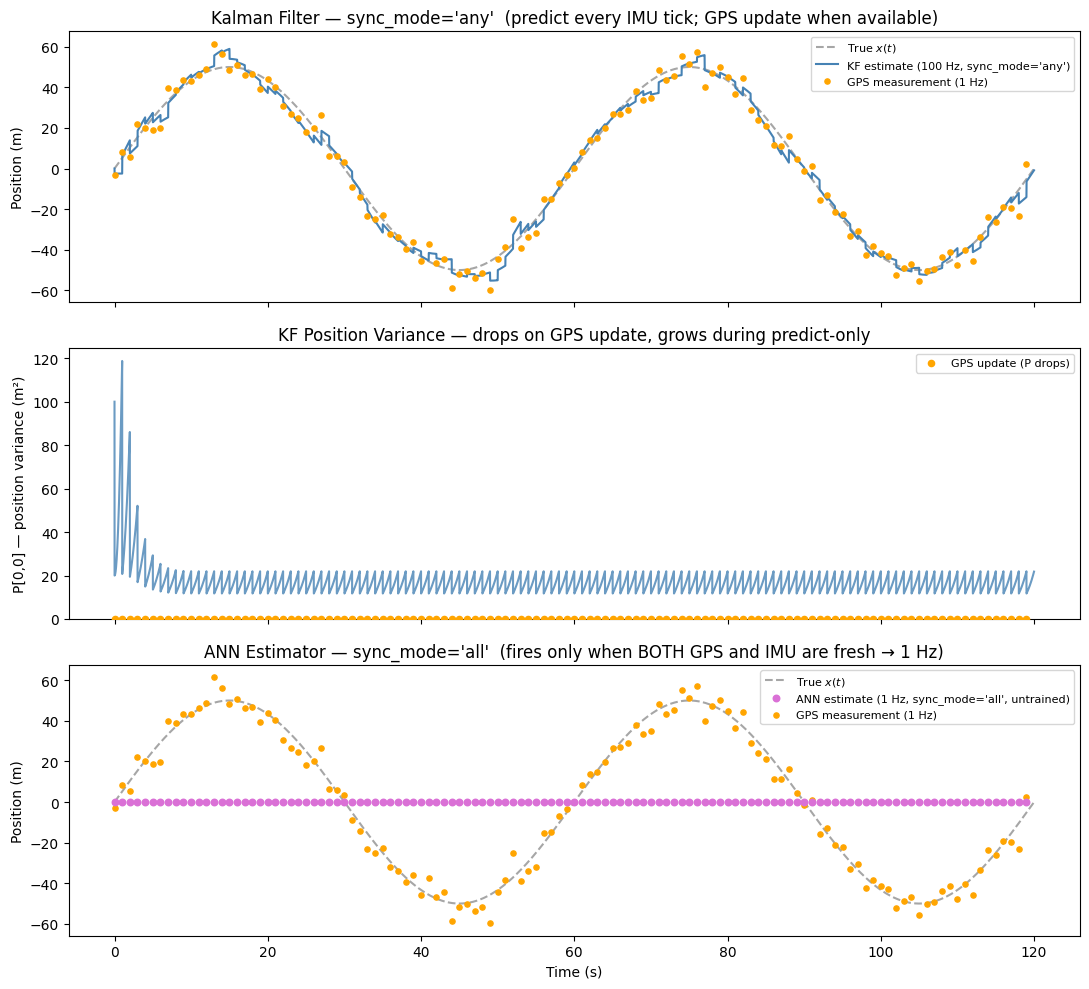

In [8]:
gps_tks, gps_xs = zip(*gps_meas_out) if gps_meas_out else ([], [])
ann_tks, ann_xs = zip(*ann_out)       if ann_out       else ([], [])

fig1, axs1 = plt.subplots(3, 1, sharex=True, figsize=(11, 10))

# ── KF position estimate ─────────────────────────────────────────────────────
axs1[0].plot(sim_time, true_out, "k--", alpha=0.35, label="True $x(t)$")
axs1[0].plot(sim_time, kf_out, color="steelblue",
             label="KF estimate (100 Hz, sync_mode='any')")
axs1[0].scatter(gps_tks, gps_xs, s=14, color="orange", zorder=3,
                label="GPS measurement (1 Hz)")
axs1[0].set_ylabel("Position (m)")
axs1[0].set_title("Kalman Filter — sync_mode='any'  "
                  "(predict every IMU tick; GPS update when available)")
axs1[0].legend(fontsize=8)

# ── KF covariance P[0,0] ─────────────────────────────────────────────────────
axs1[1].plot(sim_time, kf_P_out, color="steelblue", alpha=0.8)
axs1[1].scatter(gps_tks, [0] * len(gps_tks), s=20, color="orange",
                zorder=3, label="GPS update (P drops)")
axs1[1].set_ylabel("P[0,0] — position variance (m²)")
axs1[1].set_title("KF Position Variance — drops on GPS update, grows during predict-only")
axs1[1].set_ylim(bottom=0)
axs1[1].legend(fontsize=8)

# ── ANN estimate ─────────────────────────────────────────────────────────────
axs1[2].plot(sim_time, true_out, "k--", alpha=0.35, label="True $x(t)$")
axs1[2].scatter(ann_tks, ann_xs, s=22, color="orchid", zorder=3,
                label="ANN estimate (1 Hz, sync_mode='all', untrained)")
axs1[2].scatter(gps_tks, gps_xs, s=14, color="orange", zorder=2,
                label="GPS measurement (1 Hz)")
axs1[2].set_ylabel("Position (m)")
axs1[2].set_xlabel("Time (s)")
axs1[2].set_title("ANN Estimator — sync_mode='all'  "
                  "(fires only when BOTH GPS and IMU are fresh → 1 Hz)")
axs1[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## ROSNode Simulation — Converter Verification

This section re-runs the same loop through the `ROSNode` layer to confirm that
the `NavSatFix` and `Imu` message converters and the `DynamicalSystem` wiring
are correct before generating the deployment nodes.

Noise is added to the ROS messages directly (modifying `gps_ros.latitude` and
`imu_ros.linear_acceleration.x`) to mirror the per-field injection that will
happen in hardware.

The output should closely match Figure 1 (differences are from the independent
RNG state).

In [9]:
from dynamicalnodes import ROSNode
from sensor_msgs.msg import NavSatFix, Imu
from std_msgs.msg import Float64, Float64MultiArray
from dynamicalnodes.ros2py_py2ros import (
    ros2py_nav_sat_fix, py2ros_nav_sat_fix,
    ros2py_imu,         py2ros_imu,
    ros2py_float64,     py2ros_float64,
    ros2py_float64_multiarray, py2ros_float64_multiarray,
)

In [10]:
gps_node = ROSNode(
    dynamical_system=gps_block,
    publishes_to=[{"topic": "/gps", "msg_type": NavSatFix, "py2ros": py2ros_nav_sat_fix}],
    timer_hz=1,
)

imu_node = ROSNode(
    dynamical_system=imu_block,
    publishes_to=[{"topic": "/imu", "msg_type": Imu, "py2ros": py2ros_imu}],
    timer_hz=100,
)

# ── Kalman Filter ─────────────────────────────────────────────────────────────
# sync_mode="any": fires whenever any subscription receives a fresh message.
# At runtime: ~101 Hz (IMU at 100 Hz + GPS at 1 Hz).
# Two publishers: position estimate on /x_est_kf, covariance P[0,0] on /P_kf.
kf_node = ROSNode(
    dynamical_system=kf_block,
    subscribes_to=[
        {"topic": "/gps", "msg_type": NavSatFix, "arg": "gps",
         "ros2py": ros2py_nav_sat_fix, "stale_after": 2.0,  "buffer_size": 5},
        {"topic": "/imu", "msg_type": Imu,       "arg": "imu",
         "ros2py": ros2py_imu,         "stale_after": 0.02, "buffer_size": 20},
    ],
    publishes_to=[
        {"topic": "/x_est_kf", "msg_type": Float64, "py2ros": py2ros_float64, "key": "x_est"},
        {"topic": "/P_kf",     "msg_type": Float64, "py2ros": py2ros_float64, "key": "P00"},
    ],
    sync_mode="any",
    state_name="zk",
)

# ── ANN Estimator ─────────────────────────────────────────────────────────────
# sync_mode="all": fires only when BOTH /gps and /imu are within stale_after.
# IMU (100 Hz, stale_after=0.02 s) is almost always fresh.
# GPS (1 Hz, stale_after=2.0 s) is the bottleneck → ANN fires at ~1 Hz.
ann_node = ROSNode(
    dynamical_system=ann_block,
    subscribes_to=[
        {"topic": "/gps", "msg_type": NavSatFix, "arg": "gps",
         "ros2py": ros2py_nav_sat_fix, "stale_after": 2.0,  "buffer_size": 5},
        {"topic": "/imu", "msg_type": Imu,       "arg": "imu",
         "ros2py": ros2py_imu,         "stale_after": 0.02, "buffer_size": 20},
    ],
    publishes_to=[{"topic": "/x_est_ann", "msg_type": Float64MultiArray,
                   "py2ros": py2ros_float64_multiarray}],
    sync_mode="all",
)

In [11]:
# Initial States
kf_node._state = (np.zeros(2), np.eye(2) * 100.0)  # KF: (x_est, P)

kf_node_out, kf_P_node_out, ann_node_out = [], [], []
gps_node_out = []  # (tk, x_gps) for scatter

for i, tk in enumerate(sim_time):

    # ── IMU (100 Hz) ─────────────────────────────────────────────────────
    imu_ros = imu_node.step(tk=tk, A=A, omega=omega)
    imu_ros.linear_acceleration.x += np.random.normal(0.0, sigma_imu)

    # ── GPS (1 Hz) ───────────────────────────────────────────────────────
    gps_ros = None
    if i % gps_stride == 0:
        gps_ros = gps_node.step(tk=tk, A=A, omega=omega)
        gps_ros.latitude += np.random.normal(0.0, sigma_gps)
        gps_node_out.append((tk, gps_ros.latitude))

        # ANN (sync_mode="all" — both GPS and IMU fresh)
        ann_ros = ann_node.step(
            gps=gps_ros, imu=imu_ros, W1=W1, b1=b1, W2=W2, b2=b2
        )
        ann_node_out.append((tk, float(ann_ros.data[0])))

    # ── KF (sync_mode="any" — IMU always, GPS when available) ────────────
    kf_ros = kf_node.step(
        gps=gps_ros, imu=imu_ros, Fk=Fk, Bk=Bk, Hk=Hk, Qk=Qk, Rk=Rk
    )
    kf_node_out.append(float(kf_ros["/x_est_kf"].data))
    kf_P_node_out.append(float(kf_ros["/P_kf"].data))

kf_node.reset_simulation()

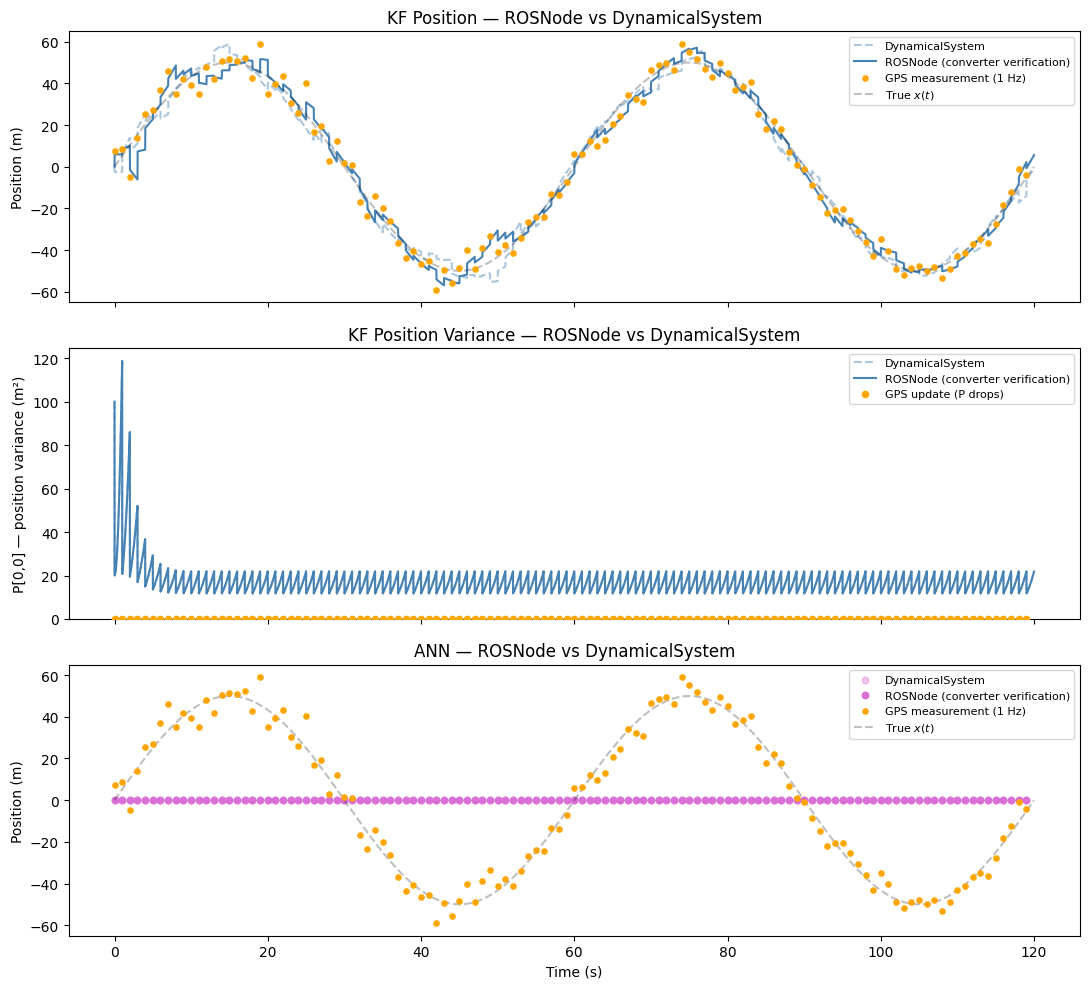

In [12]:
gps_n_tks, gps_n_xs = zip(*gps_node_out) if gps_node_out else ([], [])
ann_n_tks, ann_n_xs = zip(*ann_node_out) if ann_node_out else ([], [])

fig2, axs2 = plt.subplots(3, 1, sharex=True, figsize=(11, 10))

# ── KF position ──────────────────────────────────────────────────────────────
axs2[0].plot(sim_time, kf_out, color="steelblue", linestyle="--", alpha=0.45,
             label="DynamicalSystem")
axs2[0].plot(sim_time, kf_node_out, color="steelblue",
             label="ROSNode (converter verification)")
axs2[0].scatter(gps_n_tks, gps_n_xs, s=14, color="orange", zorder=3,
                label="GPS measurement (1 Hz)")
axs2[0].plot(sim_time, true_out, "k--", alpha=0.25, label="True $x(t)$")
axs2[0].set_ylabel("Position (m)")
axs2[0].set_title("KF Position — ROSNode vs DynamicalSystem")
axs2[0].legend(fontsize=8)

# ── KF covariance ────────────────────────────────────────────────────────────
axs2[1].plot(sim_time, kf_P_out, color="steelblue", linestyle="--", alpha=0.45,
             label="DynamicalSystem")
axs2[1].plot(sim_time, kf_P_node_out, color="steelblue",
             label="ROSNode (converter verification)")
axs2[1].scatter(gps_n_tks, [0] * len(gps_n_tks), s=20, color="orange",
                zorder=3, label="GPS update (P drops)")
axs2[1].set_ylabel("P[0,0] — position variance (m²)")
axs2[1].set_title("KF Position Variance — ROSNode vs DynamicalSystem")
axs2[1].set_ylim(bottom=0)
axs2[1].legend(fontsize=8)

# ── ANN ──────────────────────────────────────────────────────────────────────
axs2[2].scatter([t for t, _ in ann_out], [x for _, x in ann_out],
                s=22, color="orchid", alpha=0.4, label="DynamicalSystem")
axs2[2].scatter(ann_n_tks, ann_n_xs, s=22, color="orchid",
                label="ROSNode (converter verification)")
axs2[2].scatter(gps_n_tks, gps_n_xs, s=14, color="orange", zorder=3,
                label="GPS measurement (1 Hz)")
axs2[2].plot(sim_time, true_out, "k--", alpha=0.25, label="True $x(t)$")
axs2[2].set_ylabel("Position (m)")
axs2[2].set_xlabel("Time (s)")
axs2[2].set_title("ANN — ROSNode vs DynamicalSystem")
axs2[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Deploying to ROS2

`write_ROSNode_to_rclpy()` generates a self-contained rclpy Python file for each node.

The KF and ANN matrices are `static_params` — baked into the generated file at write time.
The KF matrices were already computed for `dt = 0.01 s` (100 Hz IMU rate), matching the
deployed node's effective predict rate.

| Parameter category | Used for | Examples |
|---|---|---|
| `static_params` | Constants baked in at generation — never change | `A`, `omega`, `Fk`, `W1` |
| `pub_noise` | Gaussian noise injected before publishing — for simulation testing | `{"/gps": sigma_gps}` |

**Note on IMU noise**: `pub_noise` is not used for the IMU node because it adds the
same standard deviation to *all 10 array elements*, which would corrupt the orientation
quaternion fields. In hardware deployment the IMU driver provides real sensor noise
inherently. For simulation, inject noise selectively in `imu_h` (make `sigma_imu` a
static param) rather than using `pub_noise`.

In [13]:
import os

os.makedirs("./ros_nodes", exist_ok=True)

gps_node.write_ROSNode_to_rclpy(
    "./ros_nodes/gps_node.py",
    node_name="gps",
    static_params={"A": A, "omega": omega},
    pub_noise={"/gps": sigma_gps},  # adds N(0, sigma_gps) to [lat, lon, alt]
)
imu_node.write_ROSNode_to_rclpy(
    "./ros_nodes/imu_node.py",
    node_name="imu",
    static_params={"A": A, "omega": omega},
)
kf_node.write_ROSNode_to_rclpy(
    "./ros_nodes/kf_estimator_node.py",
    node_name="kf_estimator",
    initial_state=(np.zeros(2), np.eye(2) * 100.0),
    static_params={"Fk": Fk, "Bk": Bk, "Hk": Hk, "Qk": Qk, "Rk": Rk},
    # Publishes /x_est_kf (Float64) and /P_kf (Float64) on every step.
    # In PlotJuggler: plot /P_kf/data to see variance drop on each GPS update.
)
ann_node.write_ROSNode_to_rclpy(
    "./ros_nodes/ann_estimator_node.py",
    node_name="ann_estimator",
    static_params={"W1": W1, "b1": b1, "W2": W2, "b2": b2},
)
print("Written: gps_node.py  imu_node.py  kf_estimator_node.py  ann_estimator_node.py")

Written: gps_node.py  imu_node.py  kf_estimator_node.py  ann_estimator_node.py


### Running the nodes

```bash
# Terminal 1 — GPS simulator (1 Hz)
python3 ros_nodes/gps_node.py

# Terminal 2 — IMU simulator (100 Hz)
python3 ros_nodes/imu_node.py

# Terminal 3 — KF estimator (sync_mode=any, ~101 Hz)
python3 ros_nodes/kf_estimator_node.py

# Terminal 4 — ANN estimator (sync_mode=all, ~1 Hz)
python3 ros_nodes/ann_estimator_node.py
```

**Inspect sync_mode difference at runtime:**

```bash
# KF publishes at ~101 Hz — you will see ~101 messages/sec
ros2 topic hz /x_est_kf

# ANN publishes at ~1 Hz — you will see ~1 message/sec
ros2 topic hz /x_est_ann

# Kill the GPS node — ANN stops immediately; KF keeps predicting from IMU
# (restart GPS node to resume both)
```

**Tune KF noise matrices without restarting** (promote `Qk`/`Rk` to `dynamic_params`):

```bash
ros2 param set /kf_estimator Qk "[1e-4, 0.0, 0.0, 1e-2]"
```